# just the radflux

In [1]:
import armbnfmentorer.vaps.bnfradsys43m60sS10c1 as bnfvap43
plt.rcParams['figure.dpi'] = 230

In [2]:
path_in = '/Volumes/stu3data2/bnf_radsys_data/bnfradsys43m60sS10.b1/'#'/Users/htelg/data/arm/archive/bnf/bnfradsys43m60sS10.b1/'
# path_out = '~/tmp/bnfradsys43m60sS10.c1/{version}/'#'/Users/htelg/data/arm/vap/bnfradsys43m60sS10.c1/{version}/'
radflux_parameters_db = 'bnfvap.db'
reporter = None

In [27]:
reload(bnfvap43)
reload(bnfvap43.prowo)
reload(bnfvap43.atmbrad)

<module 'atmPy.radiation.retrievals.broadband_shortwave_radiation' from '/Users/htelg/prog/atm-py/atmPy/radiation/retrievals/broadband_shortwave_radiation.py'>

In [28]:
vapi = bnfvap43.BnfRadsys43m60sS10C1Radflux(p2fld_in = path_in,
                                            path2raflux_setting = '/Users/htelg/prog/armbnfmentorer/notebooks/raflux_settings.toml',
                                             # p2fld_out = path_out, 
                                             date_from_name = lambda name: pd.to_datetime(name.split('.')[2]),
                                             output_file_format = 'bnfradsys43m60sS10.c1.{date}.nc',
                                             radflux_parameters_db = 'bnfvap.db',
                                             radflux_settings = 'defauljt', 
                                            verbose = True)
self = vapi

self.combine_masterplan_duplicates()
self.masterplan
self.workplan

start time: 2026-09-04 16:08:24.639949
Get all files in /Volumes/stu3data2/bnf_radsys_data/bnfradsys43m60sS10.b1 with glob pattern: *.nc


,p2f_in
2025-01-30,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...
2025-02-26,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...
2025-03-12,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...
2025-03-13,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...
2025-03-14,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...
...,...
2026-08-30,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...
2026-08-31,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...
2026-09-01,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...
2026-09-02,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...


30
No previous optimized clearsky parameters found for 2025-04-09T00:00:00.


Casting normalized diffuse ratio standard deviation window to int


/Users/htelg/prog/armbnfmentorer/armbnfmentorer/vaps/bnfradsys43m60sS10c1.py:114: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_wholeday = ds_wholeday.where(ds_wholeday.solar_elevation > 0, drop = True)


(-10.0, 1500.0)

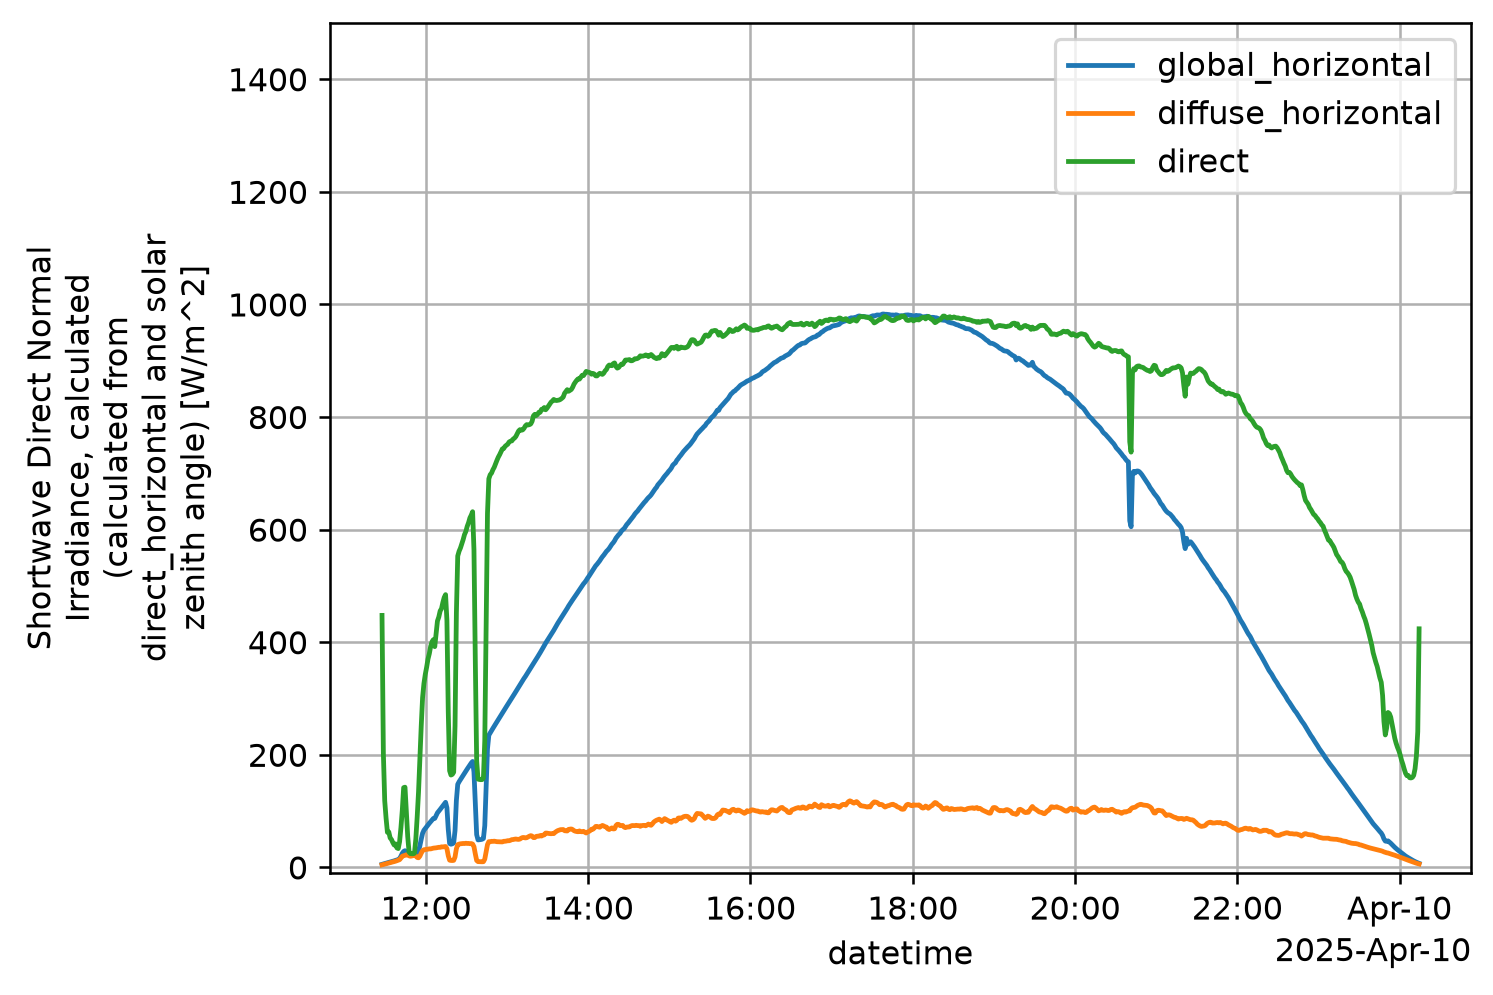

In [29]:
# row = self.workplan.loc['2026-05-14']
il = [7,11,12,30,34,35,36,37,72,73,158,159, 169,178]
# i =  428 #reverse appraoch
e = 3
# e +=1
i = il[e]
# i -=1

print(i)
out = self.process_row(iloc=i,
                       test = 1,
                        # iloc = 0, 
                       save = False)
# row = self.workplan.loc['2026-05-14']
# out = self.process_row(row = row,test = 1,
#                         # iloc = 0, 
#                        save = False)

bbi = out['bbi']
# bbi = bbi.convert2RadFlux()
# bbi.clearsky_parameters = '/Users/htelg/prog/armbnfmentorer/notebooks/raflux_settings.toml'
f,a = bbi.plot_overview()
a.set_ylim(-10, 1500)

In [30]:
res = bbi.optimize_clearsky_parameters()

################
Original values
normalized_total_shortwave_power_exponent: 1.180,
normalized_total_shortwave_lower_limit_low_sun: 900.0,
normalized_total_shortwave_lower_limit_high_sun: 1000.0,
normalized_total_shortwave_upper_limit: 1250.0,
normalized_diffuse_ratio_power_exponent: -0.800
################
Iteration 1/4
Running clear sky tests (RADFLUX equivalent)
Running normalized global magnitude test
Running diffuse magnitude test
Running global irradiance temporal gradient test
Running normalized diffuse ratio variability test
Number of clearsky (valid) points:  203
New values
normalized_total_shortwave_power_exponent: 1.2369853,
normalized_total_shortwave_lower_limit_low_sun: 992.59,
normalized_total_shortwave_lower_limit_high_sun: 992.6,
normalized_total_shortwave_upper_limit: 1292.59,
normalized_diffuse_ratio_power_exponent: -0.6656330
Reset mask_normalized_global_magnitude in dataset.
Reset mask_normalized_diffuse_ratio_variability in dataset.
Reset mask_clear_sky_shortwave in

(<Figure size 1472x1104 with 1 Axes>,
 <Axes: xlabel='datetime', ylabel='Clear sky diffuse horizontal\nirradiance (empirical power\nlaw fit) [W m-2]'>)

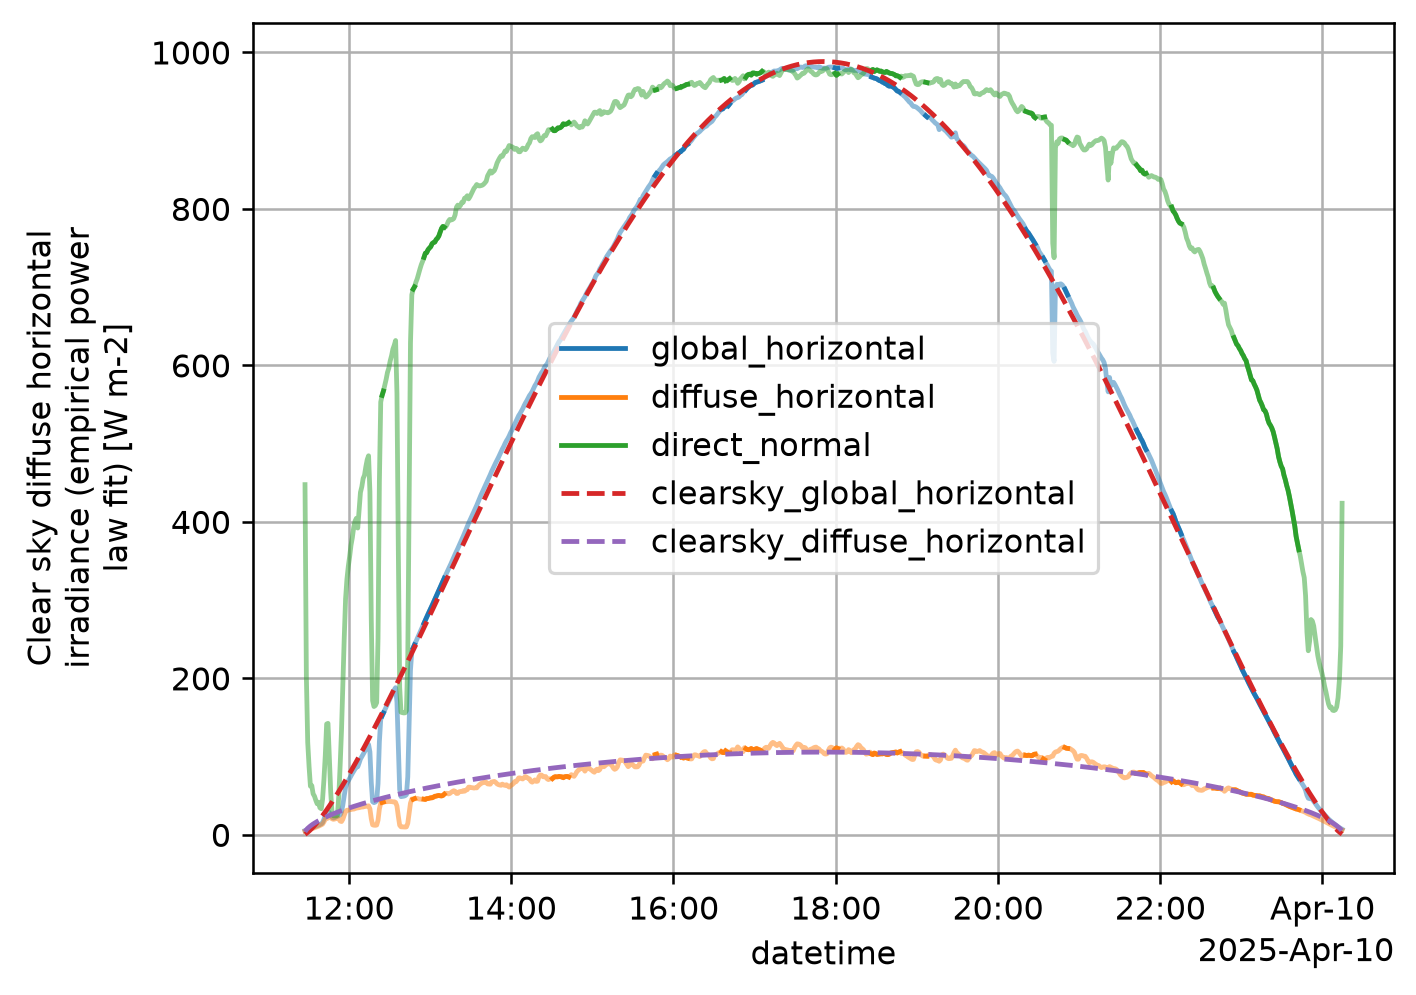

In [31]:
bbi.plot_overview(show_clearsky=True, apply_mask_clear_sky=True)

(<Figure size 1472x1656 with 2 Axes>,
 array([<Axes: title={'center': 'Normalized global power law fit'}, xlabel='mu0 (cosine of solar zenith angle)', ylabel='Normalized global SW [W m-2]'>,
        <Axes: title={'center': 'Normalized diffuse ratio power law fit'}, xlabel='mu0 (cosine of solar zenith angle)', ylabel='Normalized diffuse ratio'>],
       dtype=object))

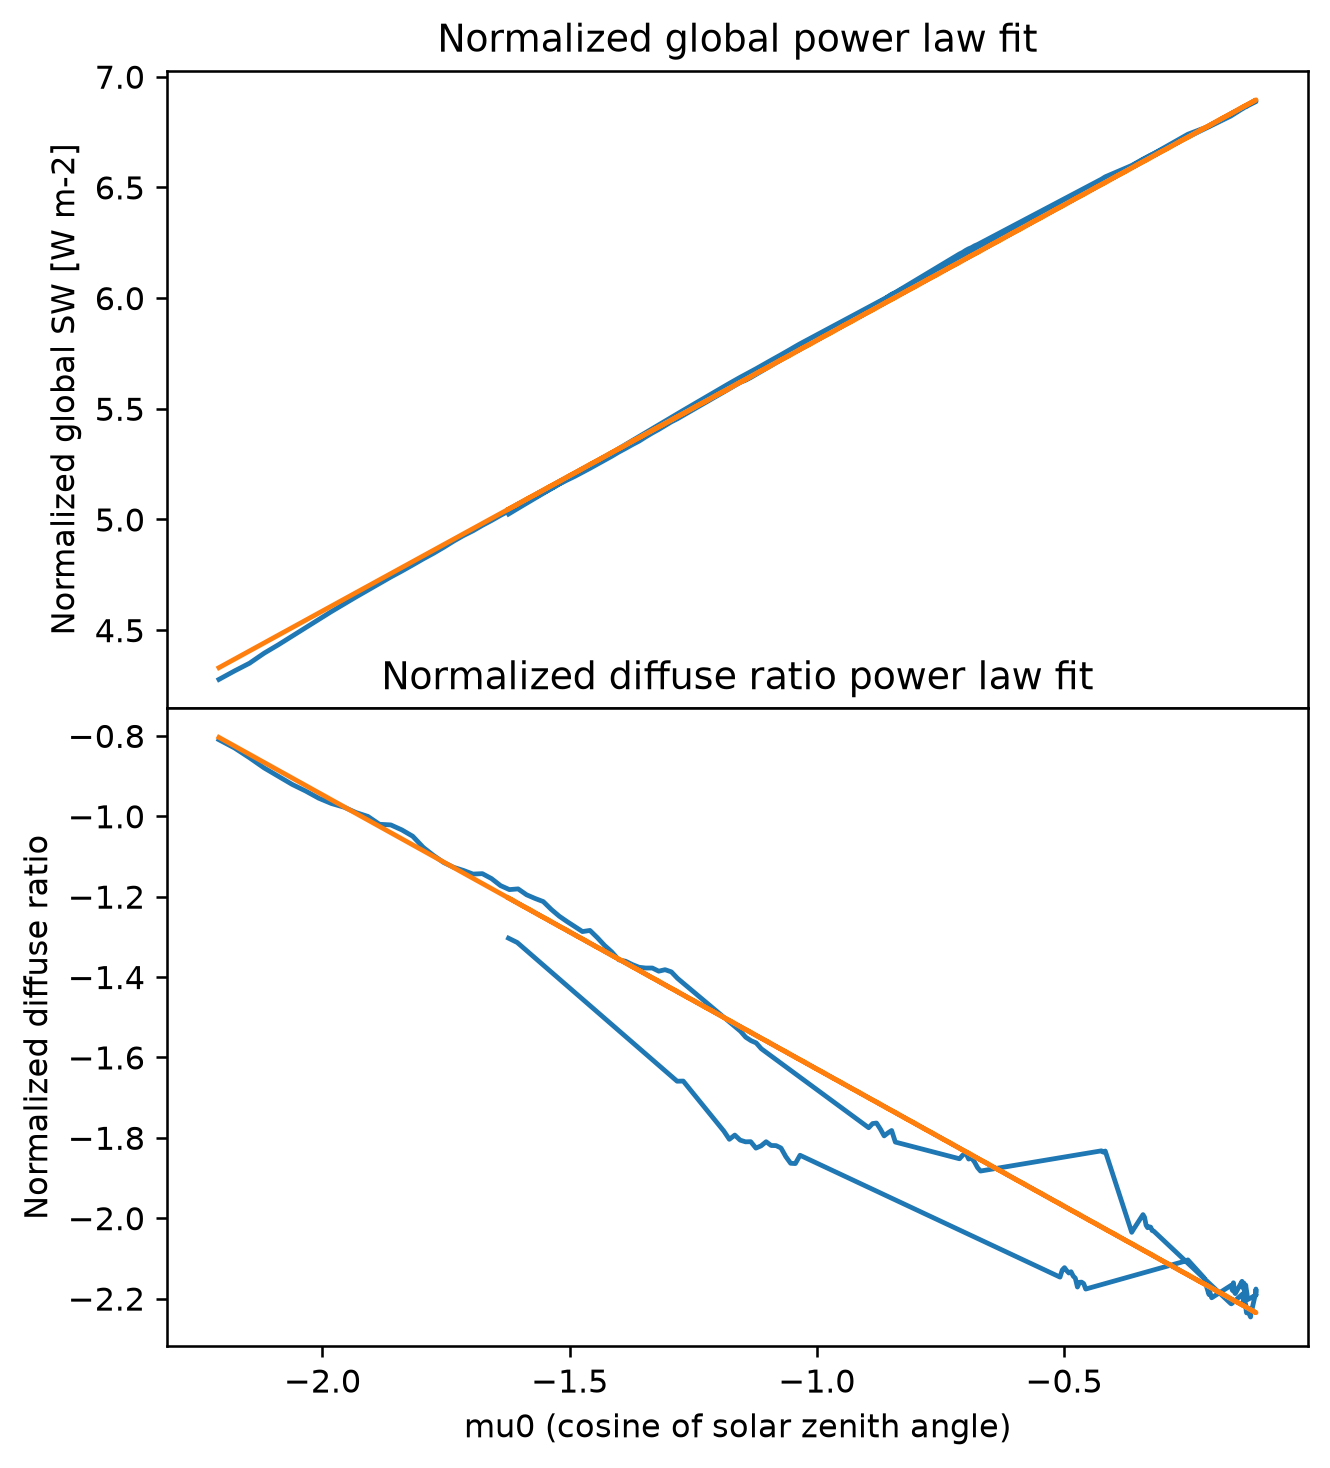

In [11]:
bbi.plot_clearsky_parameter_optimization_results()

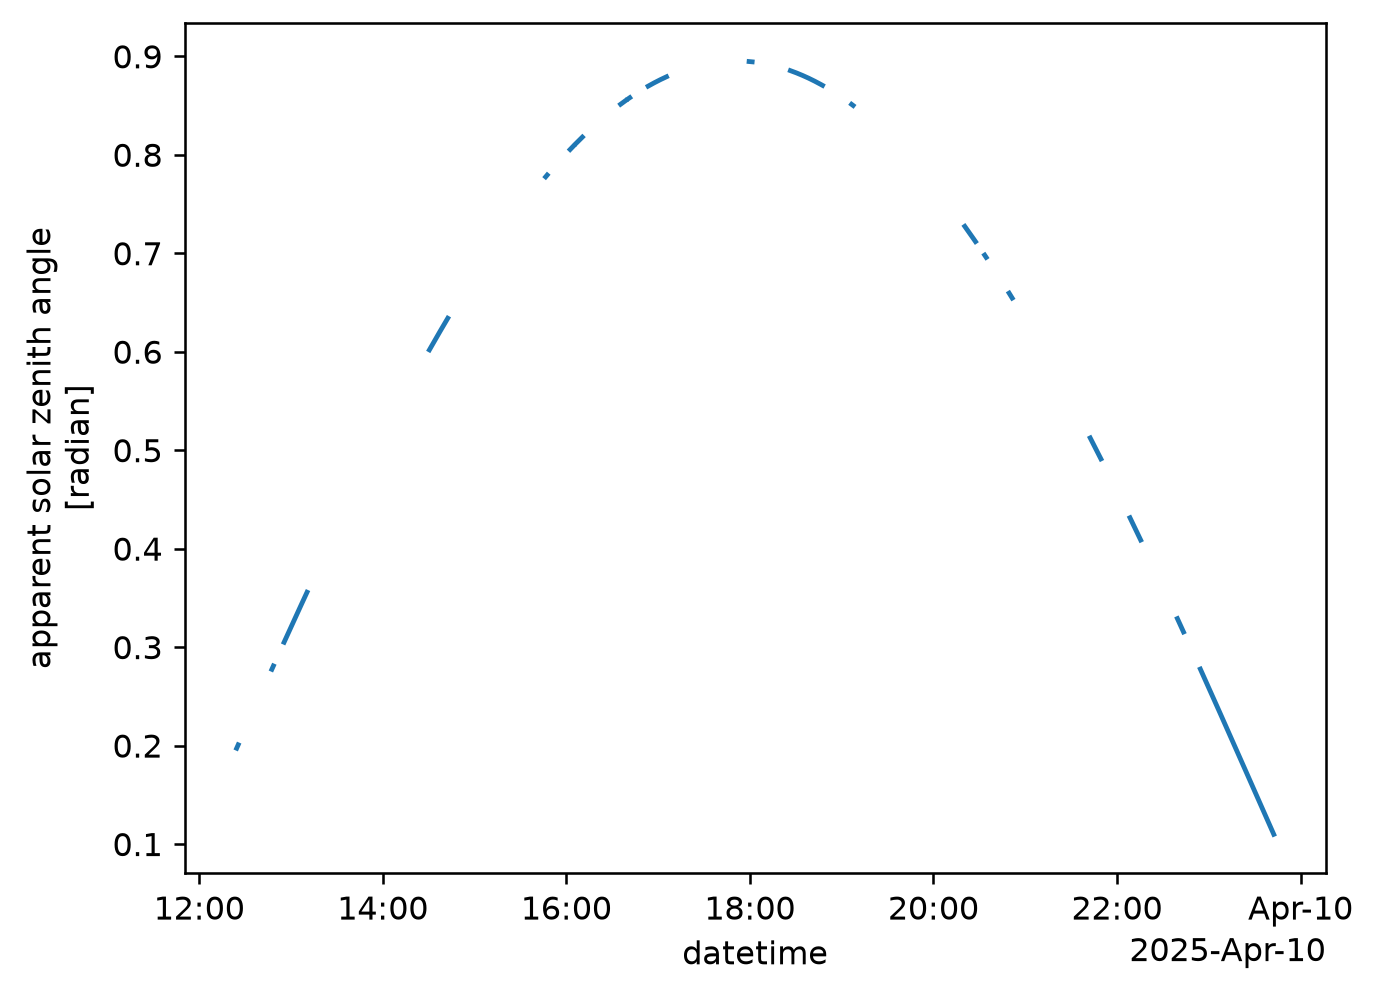

In [13]:
bbi.mu0.where(bbi.mask_clear_sky_shortwave).plot()

(<Figure size 1472x1104 with 2 Axes>,
 array([<Axes: title={'center': 'Normalized global magnitude test'}, xlabel='datetime', ylabel='Normalized SW [W m-2]'>,
        <Axes: xlabel='datetime', ylabel='mask'>], dtype=object))

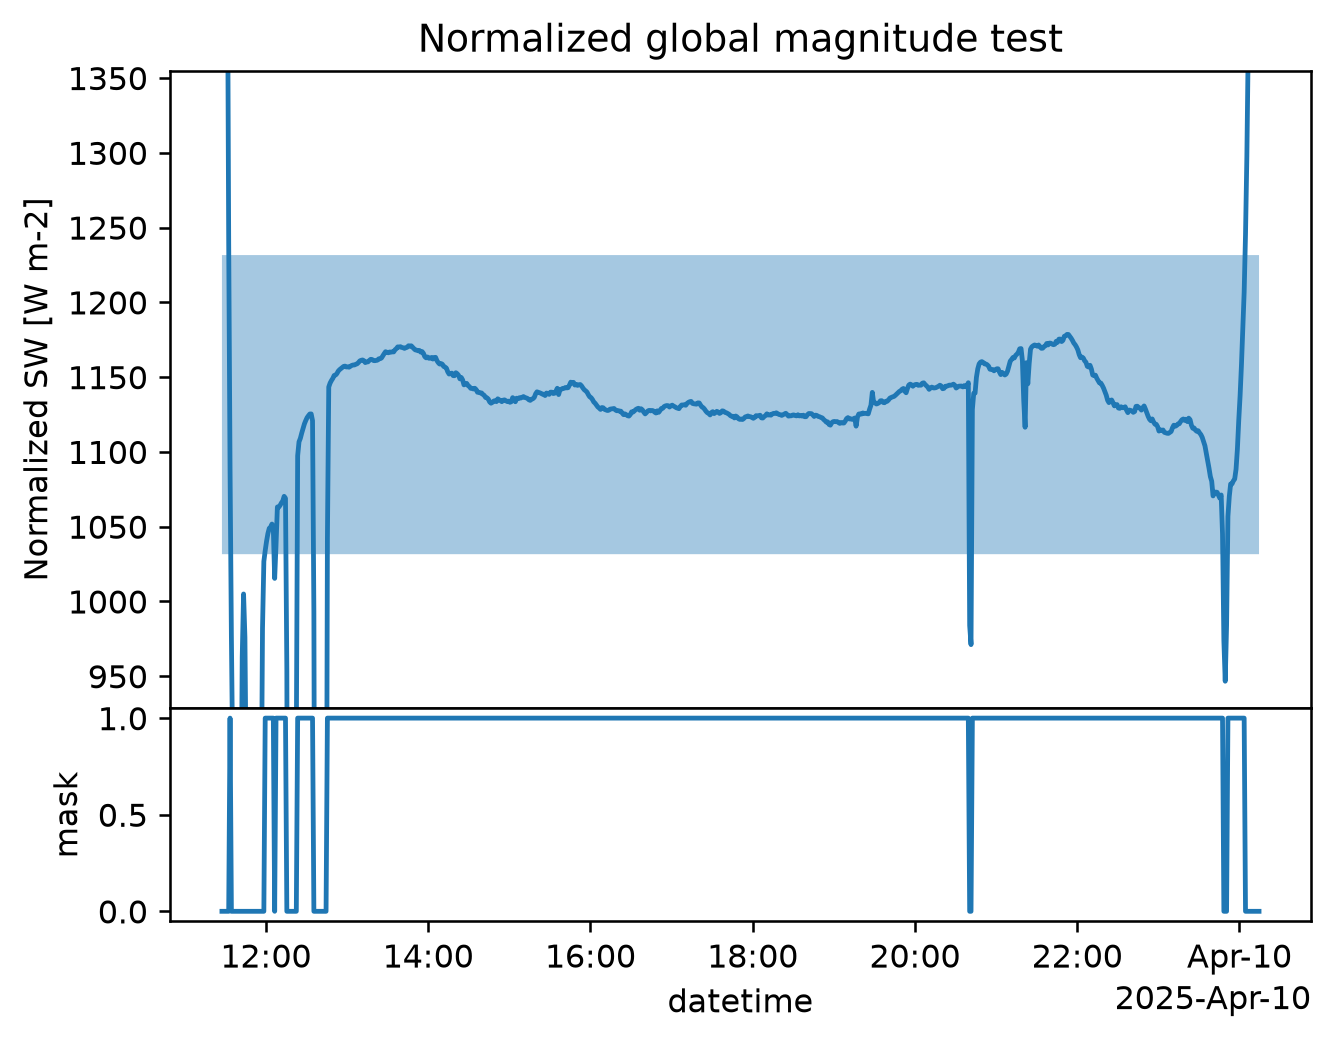

In [15]:
bbi.plot_normalized_global_magnitude_test()

(0.0, 10.0)

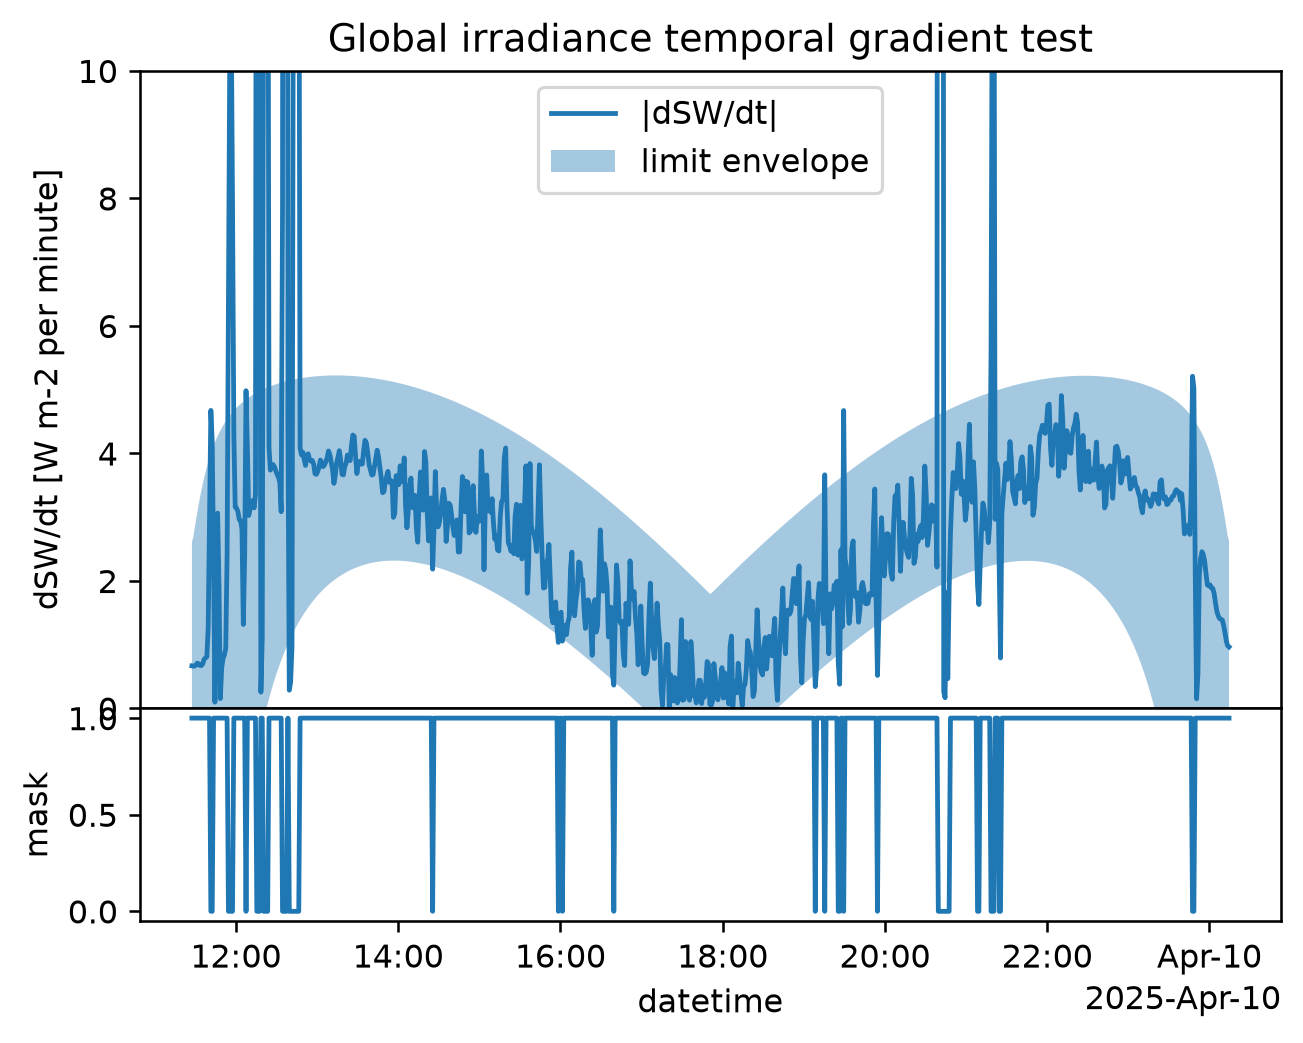

In [16]:
f,aa = bbi.plot_global_irradiance_temporal_gradient_test()
a = aa[0]
a.set_ylim(0,10)

(<Figure size 1472x1104 with 2 Axes>,
 array([<Axes: title={'center': 'Normalized global magnitude test'}, xlabel='datetime', ylabel='Normalized SW [W m-2]'>,
        <Axes: xlabel='datetime', ylabel='mask'>], dtype=object))

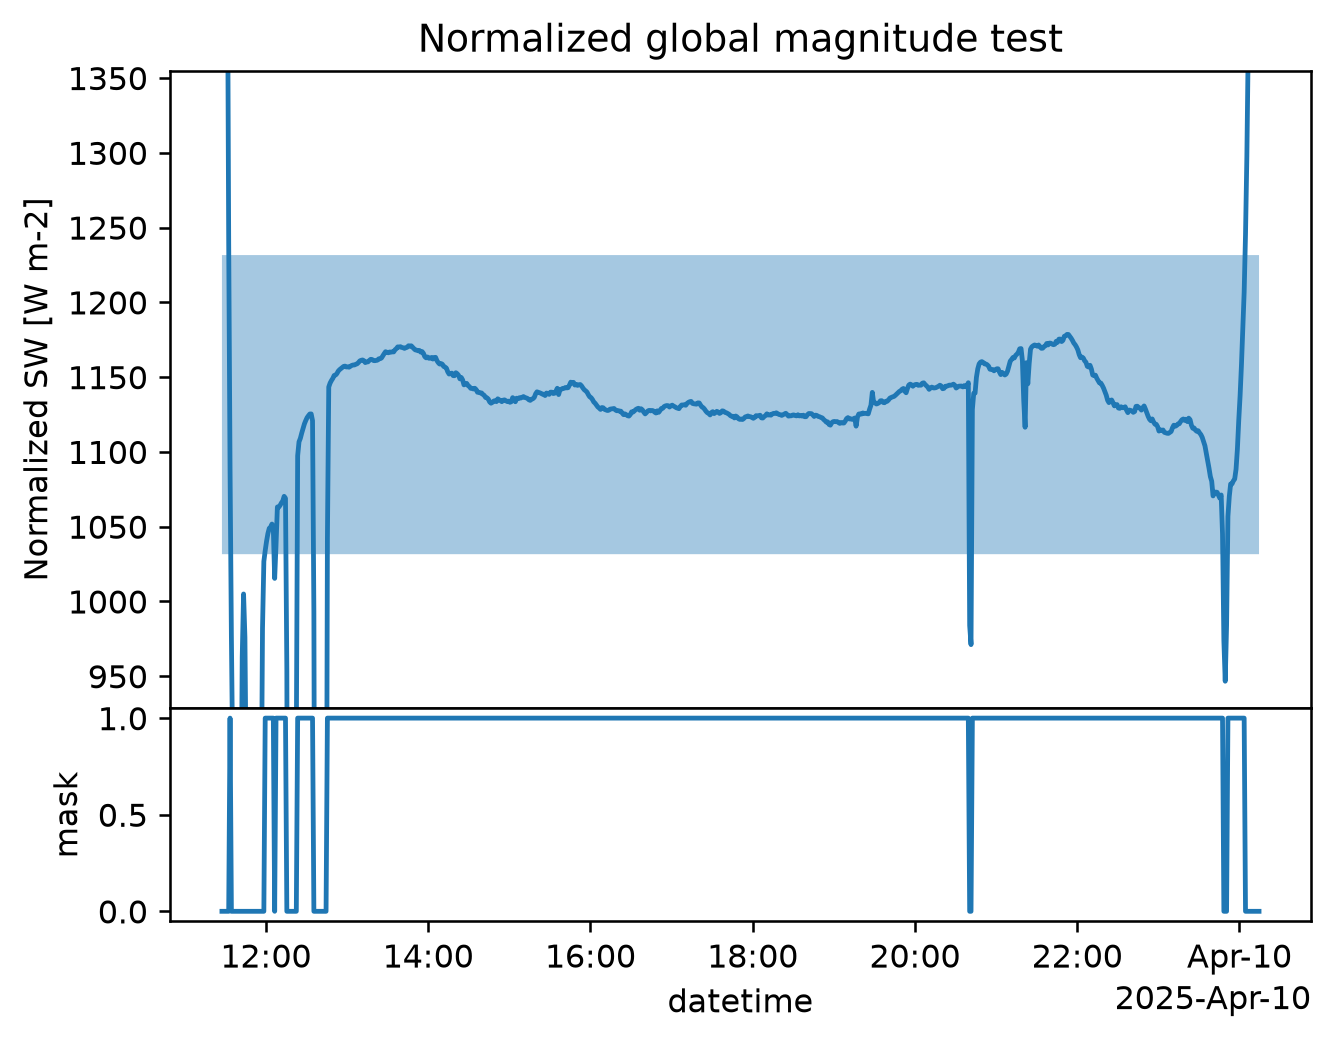

In [18]:
bbi.plot_normalized_global_magnitude_test()

In [19]:
# %matplotlib widget

(0.0, 0.01)

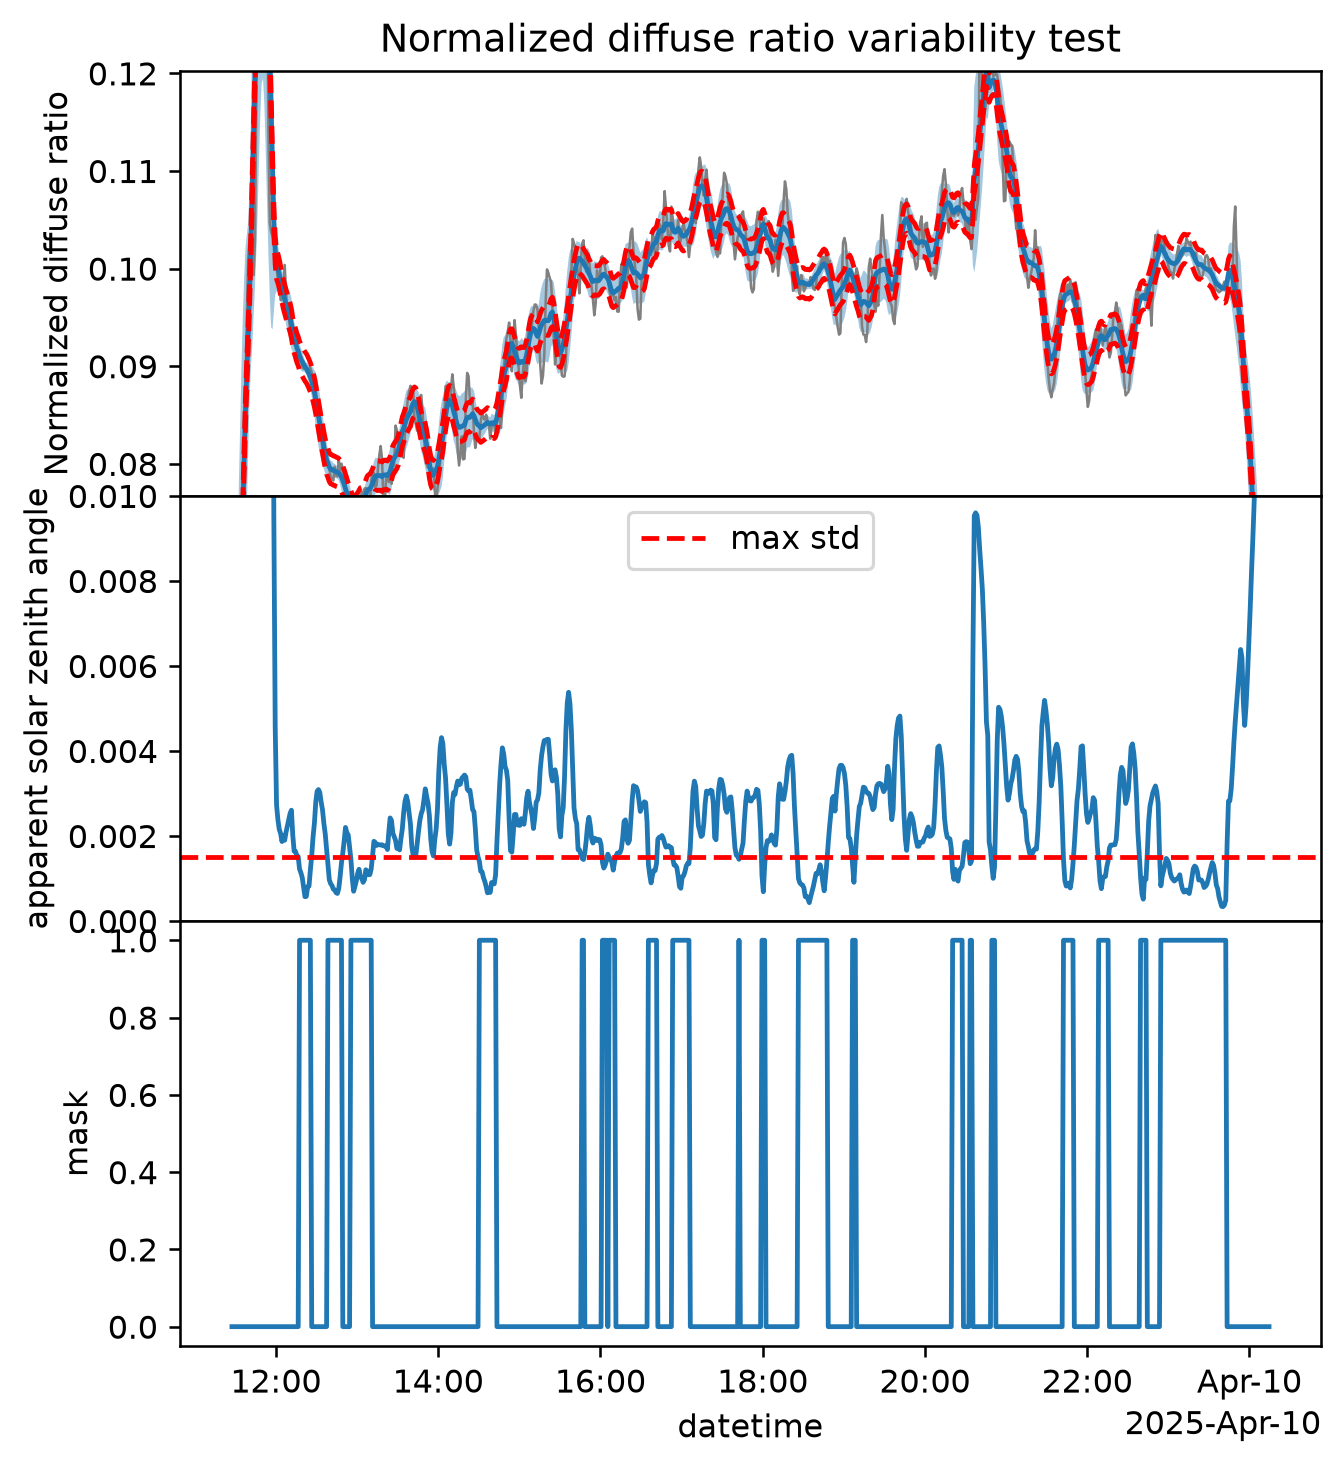

In [20]:
f,aa = bbi.plot_normalized_diffuse_ratio_variability_test()
a = aa[1]
a.set_ylim(0,0.01)

173

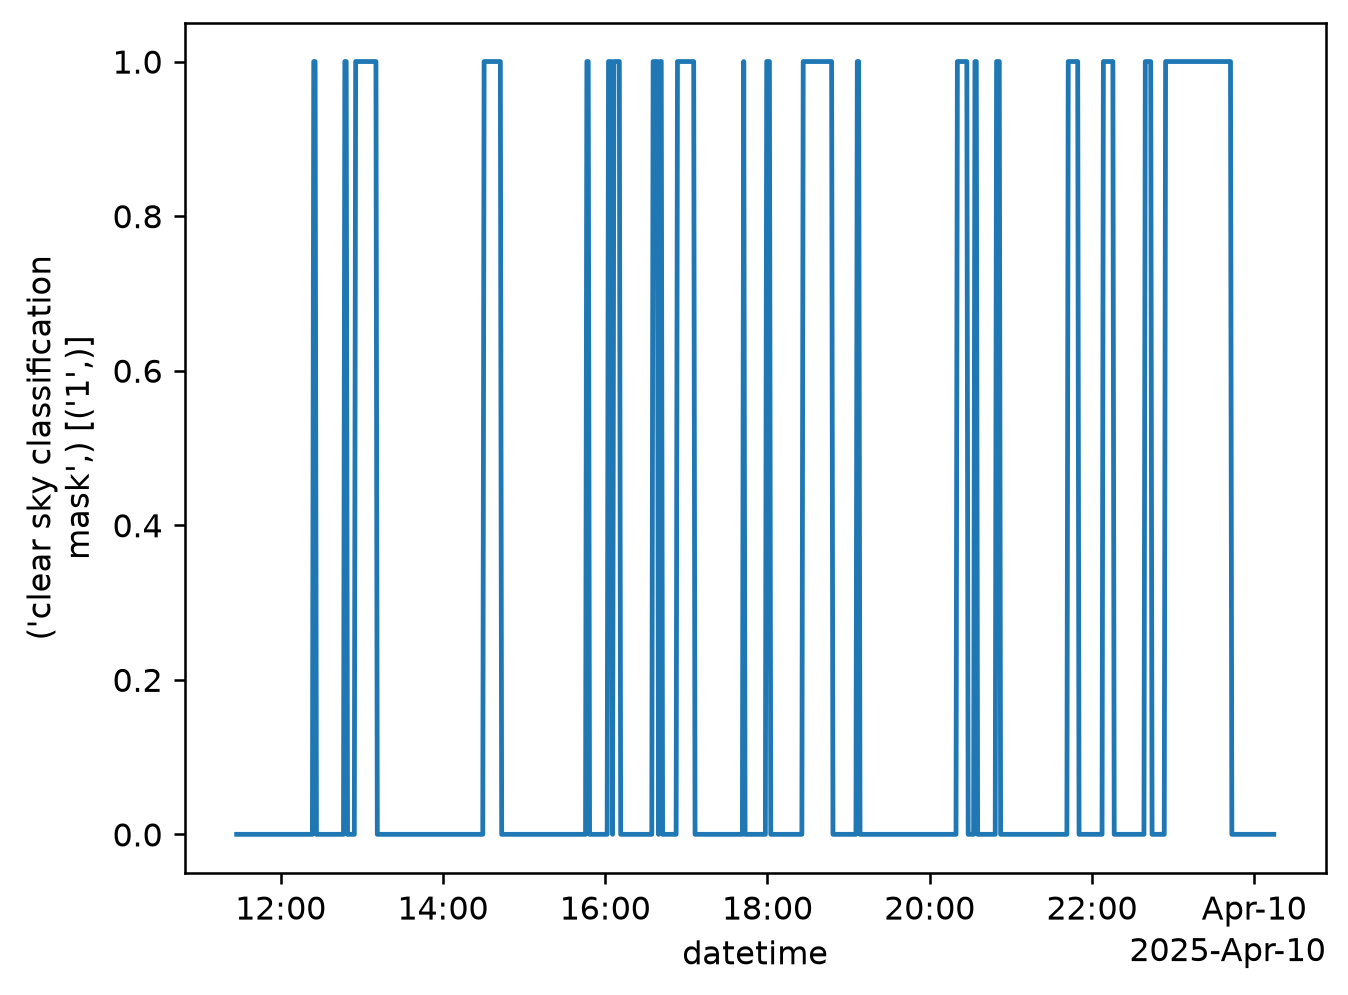

In [23]:
bbi.mask_clear_sky_shortwave.plot()
int(bbi.mask_clear_sky_shortwave.sum())

In [7]:
ds = out.dataset.compute()

NameError: name 'out' is not defined

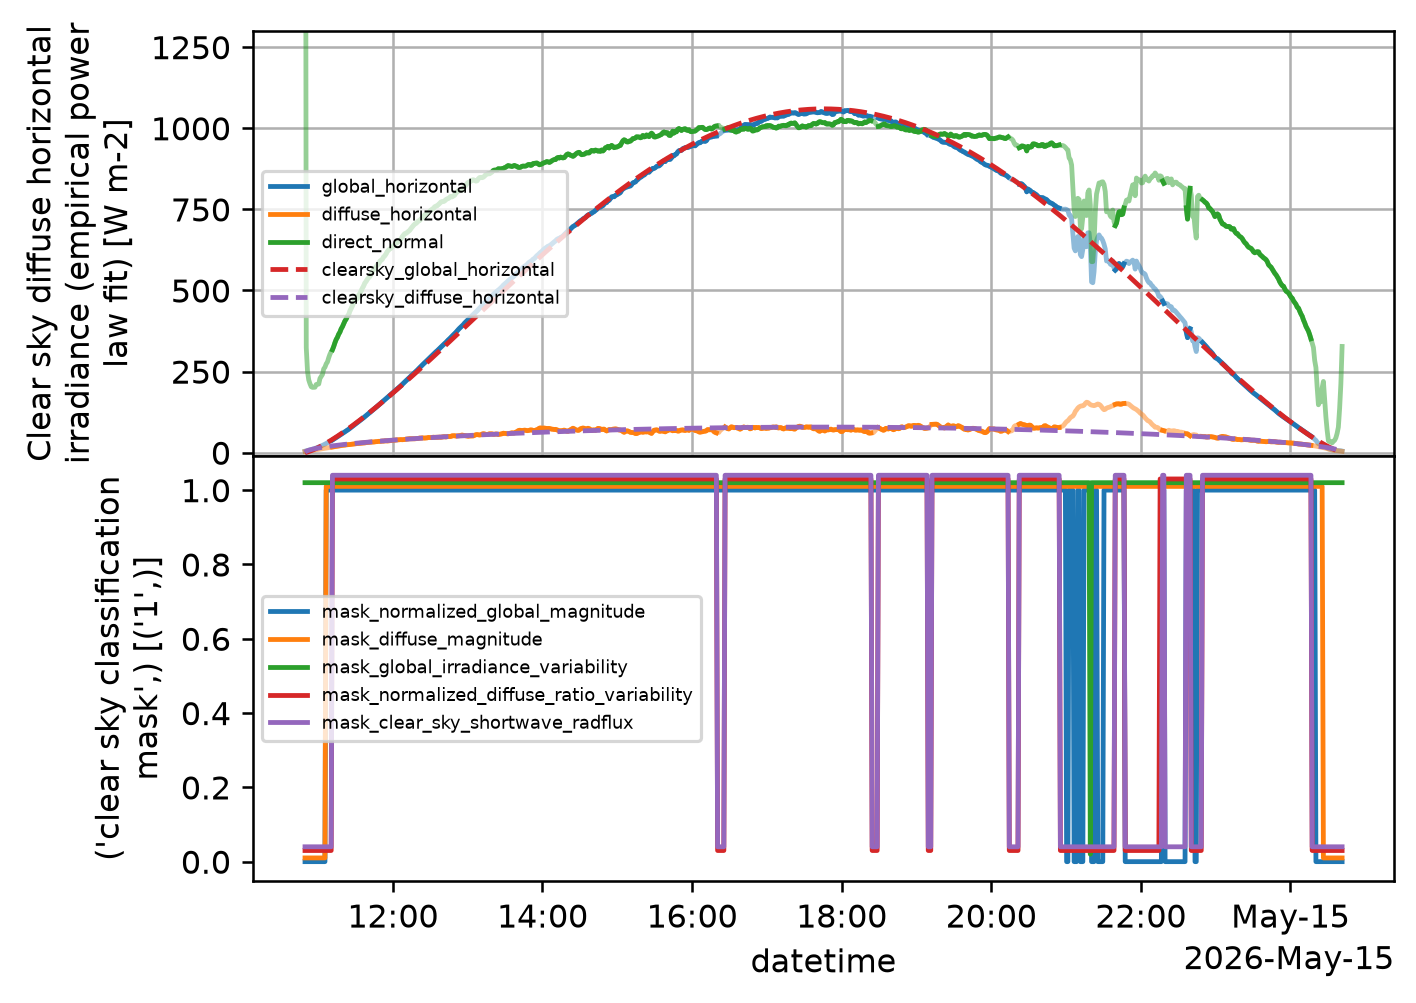

In [36]:
f,aa = plt.subplots(2, sharex=True, gridspec_kw={'hspace': 0})
a = aa[0]
out.plot_overview(show_clearsky=True, apply_mask_clear_sky = True, ax = a)
a.set_ylim(-10, 1300)

a.legend(loc = 6, fontsize = 'xx-small')
#################
# f,a = plt.subplots()
a = aa[1]
dx = 0.01

varlist = [var for var in ds if 'mask_' in var]
for e,var in enumerate(varlist):
    da = ds[var]
    (da + (e*dx)).plot(ax = a, 
                       label = var,
                      )
    # break
a.legend(loc = 6, fontsize = 'xx-small')

In [26]:
da.long_name

('clear sky classification mask',)

In [98]:
self.process(raise_errors=True)

We have to wait for the next day to to finish this local day.
.

# check the radflux parameters

In [9]:
df = self.radflux_db.dump_radflux_parameters()

In [10]:
df.index = df.apply(lambda row: pd.to_datetime(row.name), axis =1 )

In [11]:
df.dropna()

,input_file,next_day_needed,processed_at,process_version,processing_server,clear_sky_params_optimized,nsw_exp,nsw_min,nsw_max,ndr_exp,...,diffuse_max_exp,max_dsw_dt,ndr_std_max,ndr_window,nsw_coeff,nsw_r2,ndr_std_max_estimated,normalized_diffuse_fit_exp,normalized_diffuse_fit_coeff,max_dsw_dt_estimated
2026-05-14,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...,1,2026-07-15T13:42:55.541768,0.1,telg-mbp.cmdl.noaa.gov,True,1.157392,1066.843736,1119.698208,-0.903453,...,0.5,75.0,0.005,11.0,1092.502631,0.999505,0.003779,0.259245,76.054698,6.881960
2026-05-12,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...,1,2026-07-15T13:42:55.230985,0.1,telg-mbp.cmdl.noaa.gov,True,1.095200,1042.724218,1075.919669,-1.527102,...,0.5,75.0,0.005,11.0,1059.846147,0.999361,0.002577,-0.445910,74.350694,8.134864
2026-05-04,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...,1,2026-07-15T13:42:54.025897,0.1,telg-mbp.cmdl.noaa.gov,True,1.140858,1051.690617,1102.764307,-1.026140,...,0.5,75.0,0.005,11.0,1078.884252,0.997361,0.003849,0.114729,96.408227,8.617167
2026-05-03,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...,1,2026-07-15T13:42:53.852024,0.1,telg-mbp.cmdl.noaa.gov,True,1.174942,1075.076248,1139.052175,-0.758809,...,0.5,75.0,0.005,11.0,1107.152557,0.999440,0.002866,0.417127,92.051773,7.368425
2026-04-19,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...,1,2026-07-15T13:42:50.830712,0.1,telg-mbp.cmdl.noaa.gov,True,1.190689,1119.657390,1177.968336,-0.656720,...,0.5,75.0,0.005,11.0,1148.340298,0.999719,0.002125,0.520967,105.745575,9.713249
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-23,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...,1,2026-07-15T13:41:59.699798,0.1,telg-mbp.cmdl.noaa.gov,True,1.235715,1065.326760,1178.956533,-0.323334,...,0.5,75.0,0.005,11.0,1121.463650,0.999072,0.005547,0.856913,161.220809,9.651587
2025-03-22,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...,1,2026-07-15T13:41:59.527728,0.1,telg-mbp.cmdl.noaa.gov,True,1.190711,1065.269942,1245.194781,-0.628281,...,0.5,75.0,0.005,11.0,1155.405605,0.998932,0.002517,0.555427,102.554176,7.662941
2025-03-21,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...,1,2026-07-15T13:41:59.377495,0.1,telg-mbp.cmdl.noaa.gov,True,1.199695,1160.151069,1231.408872,-0.572629,...,0.5,75.0,0.005,11.0,1194.043661,0.999725,0.002652,0.627064,93.242479,6.908359
2025-03-18,/Volumes/stu3data2/bnf_radsys_data/bnfradsys43...,0,2026-07-15T13:41:58.913301,0.1,telg-mbp.cmdl.noaa.gov,True,1.184232,1138.424512,1200.764043,-0.721578,...,0.5,75.0,0.005,11.0,1168.613569,0.999555,0.003616,0.462655,85.183196,9.799199


In [13]:
for c in df.columns:
    print(c)

input_file
next_day_needed
processed_at
process_version
processing_server
clear_sky_params_optimized
nsw_exp
nsw_min
nsw_max
ndr_exp
mu0_min
diffuse_max_coeff
diffuse_max_exp
max_dsw_dt
ndr_std_max
ndr_window
nsw_coeff
nsw_r2
ndr_std_max_estimated
normalized_diffuse_fit_exp
normalized_diffuse_fit_coeff
max_dsw_dt_estimated


<Axes: >

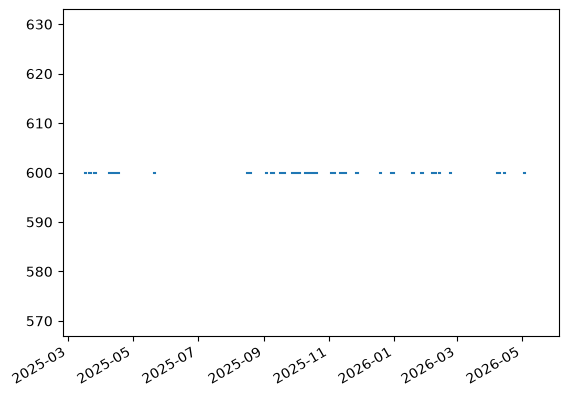

In [14]:
df.diffuse_max_coeff.plot()

<Axes: >

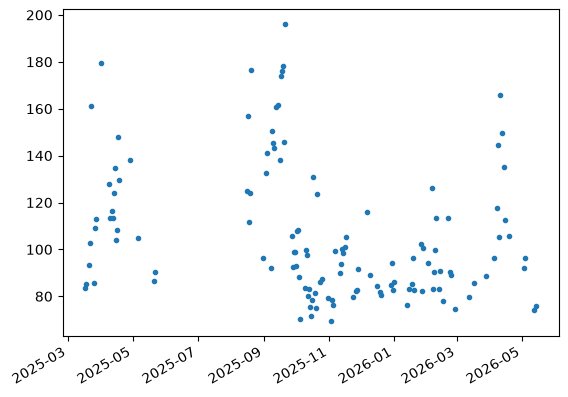

In [16]:
df.normalized_diffuse_fit_coeff.plot(ls= '', marker = '.')

<Axes: >

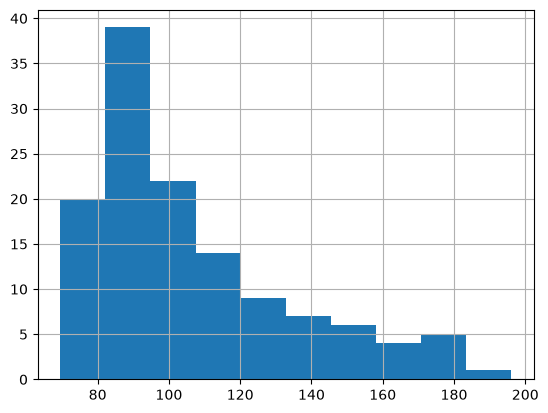

In [17]:
df.normalized_diffuse_fit_coeff.hist()

In [101]:
[c for c in df.columns if 'nsw' in c]

['nsw_exp', 'nsw_min', 'nsw_max', 'nsw_coeff', 'nsw_r2']

In [102]:
plt.rcParams['figure.dpi']= 200

<Axes: >

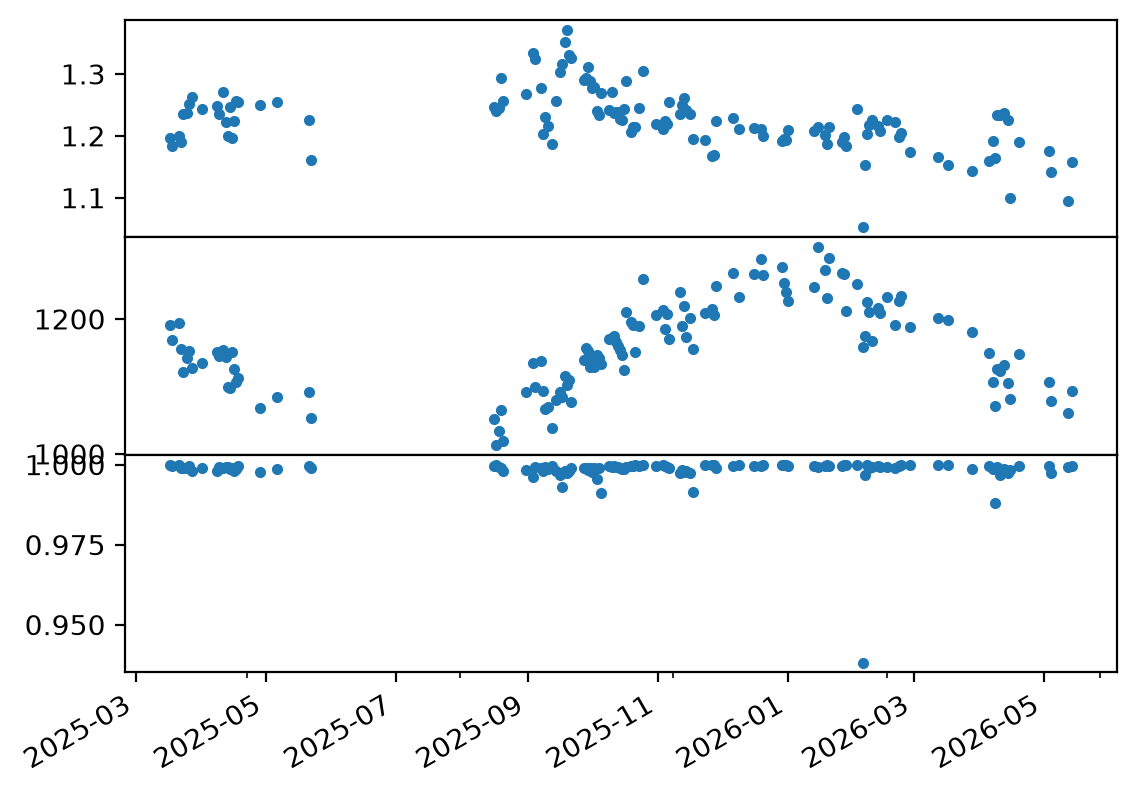

In [103]:
f,aa = plt.subplots(3, sharex=True, gridspec_kw={'hspace' : 0})
########
a = aa[0]
df.nsw_exp.plot(ls = '', marker ='.', ax = a)

##########
a = aa[1]
df.nsw_coeff.plot(ls = '', marker ='.', ax = a)

#########

a = aa[2]
df.nsw_r2.plot(ls = '', marker ='.', ax = a)


# f.autofmt_xdate()